In [17]:
# Basic
import os
from os import makedirs
from os import listdir
from shutil import copyfile
from random import seed
from random import random
import numpy as np
import pandas as pd
import cv2
# visuals
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

# Tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense,MaxPooling2D,Dropout,Flatten,BatchNormalization,Conv2D
from tensorflow.keras.callbacks import ReduceLROnPlateau,EarlyStopping

In [18]:
dataset_dir = "D:\\cat_dog_keras\\dataset"

filenames = os.listdir(dataset_dir)
labels = [x.split(".")[0] for x in filenames]

df = pd.DataFrame({"filename": filenames, "label": labels})

df.head()
df.tail()

,filename,label
9995,dog.995.jpg,dog
9996,dog.996.jpg,dog
9997,dog.997.jpg,dog
9998,dog.998.jpg,dog
9999,dog.999.jpg,dog


In [19]:
df["label"].value_counts()
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))  # fractions

label
cat    5000
dog    5000
Name: count, dtype: int64
label
cat    0.5
dog    0.5
Name: proportion, dtype: float64


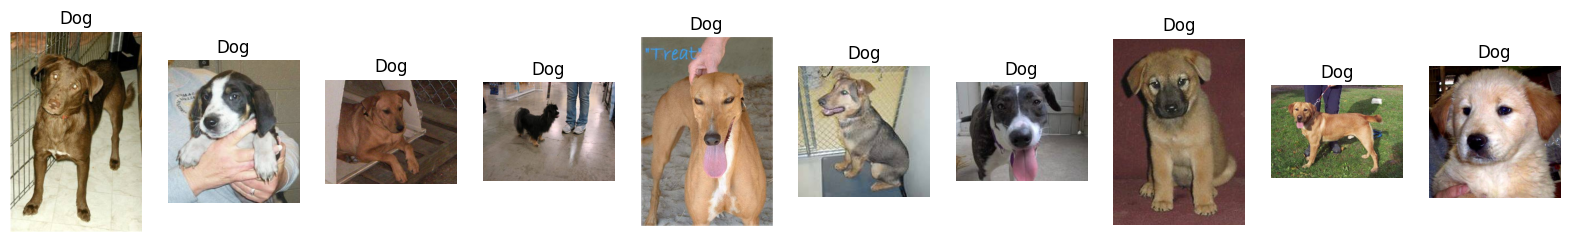

In [23]:
plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0.4)

# collect dog image filenames from the dataset listing
dog_files = [f for f in filenames if f.startswith('dog.')]
dog_files = sorted(dog_files)

for i, fname in enumerate(dog_files[:10]):
    plt.subplot(1,10,i+1)
    path = os.path.join(dataset_dir, fname)
    image = imread(path)
    plt.imshow(image)
    plt.title('Dog', fontsize=12)
    plt.axis('off')

plt.show()

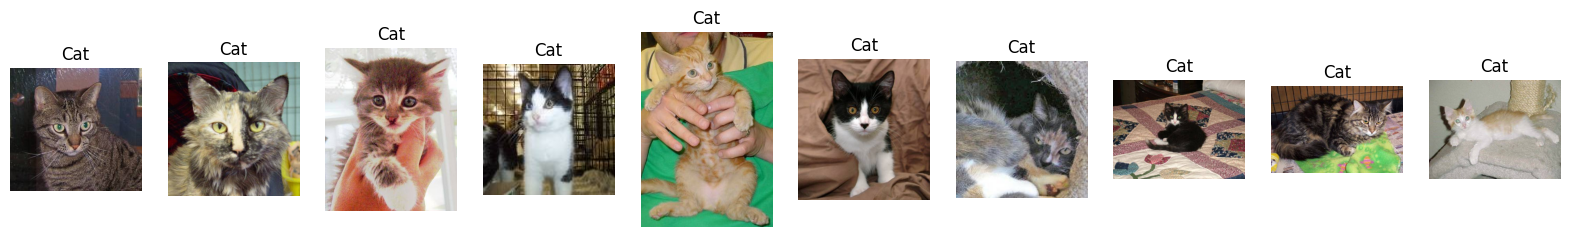

In [24]:
plt.figure(figsize=(20,20))
plt.subplots_adjust(hspace=0.4)

# collect cat image filenames from the dataset listing
cat_files = [f for f in filenames if f.startswith('cat.')]
cat_files = sorted(cat_files)

for i, fname in enumerate(cat_files[:10]):
    plt.subplot(1,10,i+1)
    path = os.path.join(dataset_dir, fname)
    image = imread(path)
    plt.imshow(image)
    plt.title('Cat', fontsize=12)
    plt.axis('off')

plt.show()

In [25]:
# train test split using dataframe

labels = df['label']

X_train, X_temp = train_test_split(df, test_size=0.2, stratify=labels, random_state = 42)

label_test_val = X_temp['label']

X_test, X_val = train_test_split(X_temp, test_size=0.5, stratify=label_test_val, random_state = 42)

print('The shape of train data',X_train.shape)
print('The shape of test data',X_test.shape)
print('The shape of validation data',X_val.shape)

The shape of train data (8000, 2)
The shape of test data (1000, 2)
The shape of validation data (1000, 2)


In [27]:
X_train["label"].value_counts()
X_test["label"].value_counts()
X_val["label"].value_counts()
print(X_train["label"].value_counts())
print(X_test["label"].value_counts())
print(X_val["label"].value_counts())

label
cat    4000
dog    4000
Name: count, dtype: int64
label
dog    500
cat    500
Name: count, dtype: int64
label
dog    500
cat    500
Name: count, dtype: int64


In [32]:
# Define ImageDataGenerator for training and testing/validation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# For validation and test we only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

In [33]:
# Applying image data generator to train and test data
image_size = 128
image_channel = 3  
bat_size = 32

train_generator = train_datagen.flow_from_dataframe(
    X_train,
    directory=dataset_dir,
    x_col='filename',
    y_col='label',
    batch_size=bat_size,
    target_size=(image_size,image_size)
)

val_generator = test_datagen.flow_from_dataframe(
    X_val,
    directory=dataset_dir,
    x_col='filename',
    y_col='label',
    batch_size=bat_size,
    target_size=(image_size,image_size),
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    X_test,
    directory=dataset_dir,
    x_col='filename',
    y_col='label',
    batch_size=bat_size,
    target_size=(image_size,image_size),
    shuffle=False
)


Found 8000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.
Found 1000 validated image filenames belonging to 2 classes.


In [34]:
model = Sequential()

# Input Layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape = (image_size,image_size,image_channel))) 
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Bloack 1 
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
# Block 2
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
# Block 3
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

# Fully Connected layers 
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

# Output layer
model.add(Dense(2,activation='softmax'))

model.summary()

d:\cat_dog_keras\venv_cnn\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,112,514 (19.50 MB)

 Trainable params: 5,110,530 (19.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [35]:
learning_rate_reduction = ReduceLROnPlateau(monitor = 'val_accuracy',
                                            patience=2,
                                            factor=0.5,
                                            min_lr = 0.00001,
                                            verbose = 1)

early_stoping = EarlyStopping(monitor='val_loss',patience= 3,restore_best_weights=True,verbose=0)

In [36]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [37]:
cat_dog = model.fit(train_generator,
                    validation_data = val_generator, 
                    callbacks=[early_stoping,learning_rate_reduction],
                    epochs = 30,
                    # steps_per_epoch = len(train_generator),
                    # validation_steps = len(val_generaotor),
                   )

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 227s 894ms/step - accuracy: 0.6200 - loss: 0.7466 - val_accuracy: 0.5780 - val_loss: 0.7260 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 163s 650ms/step - accuracy: 0.6476 - loss: 0.6515 - val_accuracy: 0.5360 - val_loss: 1.1198 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 185s 740ms/step - accuracy: 0.6880 - loss: 0.6019 - val_accuracy: 0.7160 - val_loss: 0.5430 - learning_rate: 0.0010
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 163s 652ms/step - accuracy: 0.7086 - loss: 0.5707 - val_accuracy: 0.7320 - val_loss: 0.5224 - learning_rate: 0.0010
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 179s 718ms/step - accuracy: 0.7336 - loss: 0.5389 - val_accuracy: 0.7300 - val_loss: 0.5426 - learning_rate: 0.0010
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.7482 - loss: 0.5198
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 169s 673ms/step - accuracy:

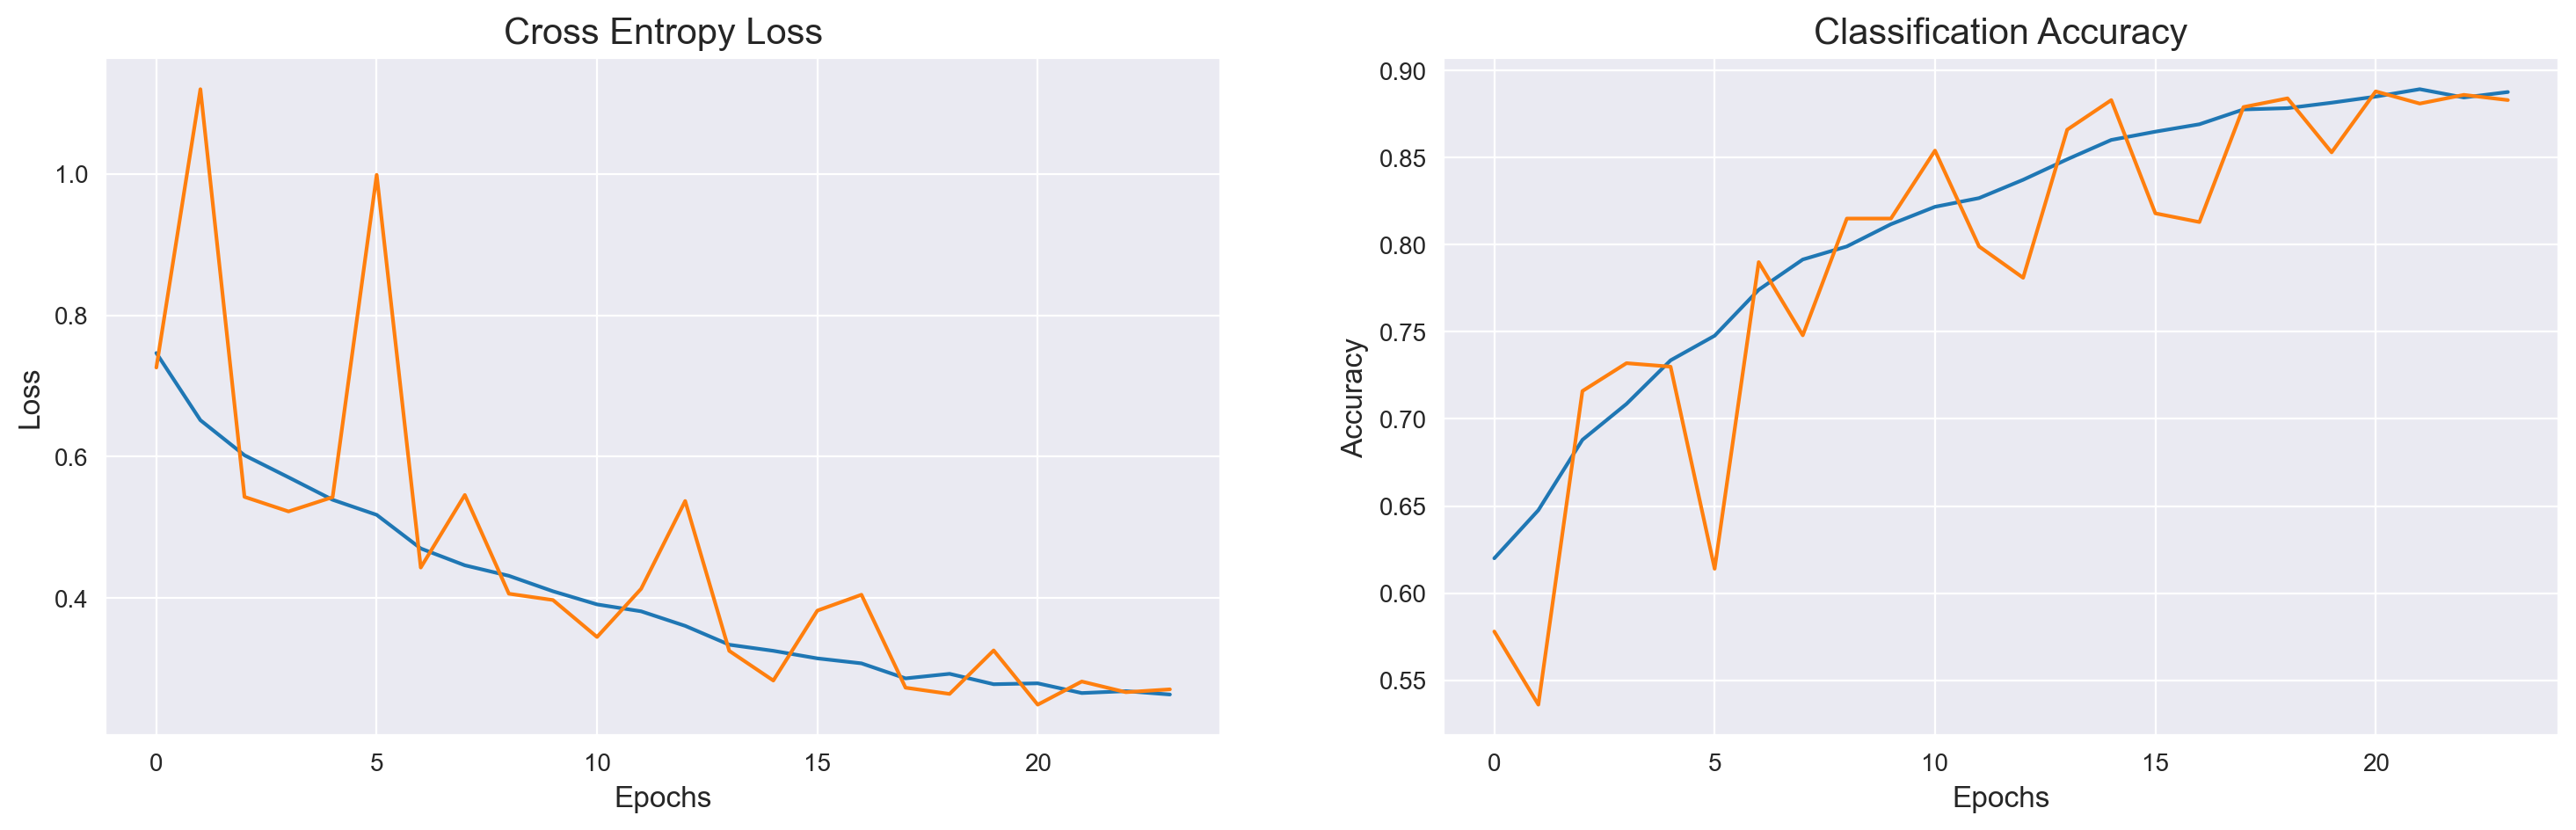

In [38]:
# plots for accuracy and Loss with epochs

error = pd.DataFrame(cat_dog.history)

plt.figure(figsize=(18,5),dpi=200)
sns.set_style('darkgrid')

plt.subplot(121)
plt.title('Cross Entropy Loss',fontsize=15)
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Loss',fontsize=12)
plt.plot(error['loss'])
plt.plot(error['val_loss'])

plt.subplot(122)
plt.title('Classification Accuracy',fontsize=15)
plt.xlabel('Epochs',fontsize=12)
plt.ylabel('Accuracy',fontsize=12)
plt.plot(error['accuracy'])
plt.plot(error['val_accuracy'])

plt.show()


In [42]:
# Evaluvate for train generator
loss,acc = model.evaluate(train_generator,batch_size = bat_size, verbose = 0)

print('The accuracy of the model for training data is:',acc*100)
print('The Loss of the model for training data is:',loss)

# Evaluvate for validation generator
loss,acc = model.evaluate(val_generator,batch_size = bat_size, verbose = 0)
print('The accuracy of the model for validation data is:',acc*100)
print('The Loss of the model for validation data is:',loss)


The accuracy of the model for training data is: 90.3124988079071
The Loss of the model for training data is: 0.23274961113929749
The accuracy of the model for validation data is: 88.80000114440918
The Loss of the model for validation data is: 0.2490561306476593


In [44]:
# Save the Model
model.save("model.h5")

In [45]:
# prediction
result = model.predict(test_generator,batch_size = bat_size,verbose = 0)

y_pred = np.argmax(result, axis = 1)

y_true = test_generator.labels

# Evaluvate
loss,acc = model.evaluate(test_generator, batch_size = bat_size, verbose = 0)

print('The accuracy of the model for testing data is:',acc*100)
print('The Loss of the model for testing data is:',loss)

The accuracy of the model for testing data is: 89.30000066757202
The Loss of the model for testing data is: 0.24939636886119843


In [46]:
labels =['Cat','Dog']
print(classification_report(y_true, y_pred,target_names=labels))

              precision    recall  f1-score   support

         Cat       0.87      0.93      0.90       500
         Dog       0.92      0.86      0.89       500

    accuracy                           0.89      1000
   macro avg       0.90      0.89      0.89      1000
weighted avg       0.90      0.89      0.89      1000



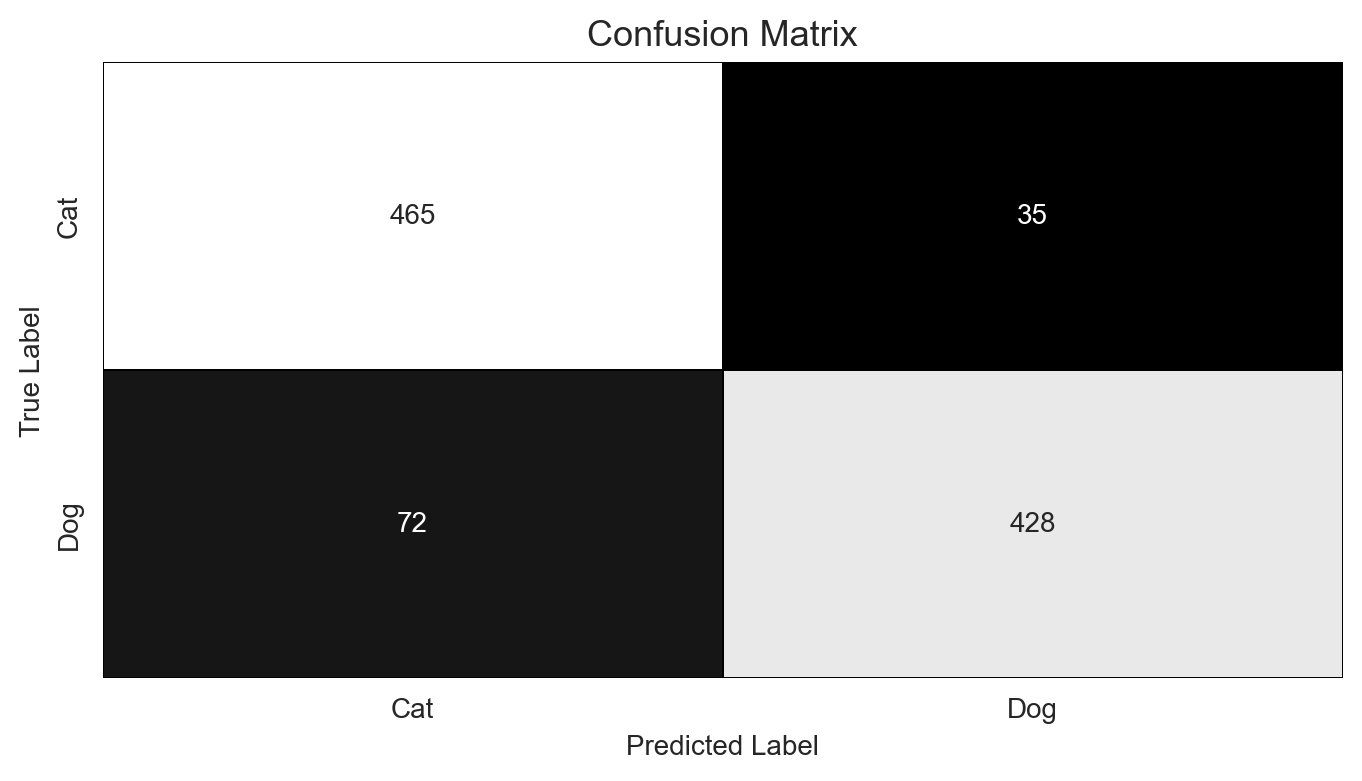

In [47]:
confusion_mtx = confusion_matrix(y_true,y_pred) 

f,ax = plt.subplots(figsize = (8,4),dpi=200)
sns.heatmap(confusion_mtx, annot=True, linewidths=0.1, cmap = "gist_yarg_r", linecolor="black", fmt='.0f', ax=ax,cbar=False, xticklabels=labels, yticklabels=labels)

plt.xlabel("Predicted Label",fontsize=10)
plt.ylabel("True Label",fontsize=10)
plt.title("Confusion Matrix",fontsize=13)

plt.show()